# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Pranaja Adyatma Budiman | 5054251009 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan.
# Import library yang dibutuhkan.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42

In [2]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.
df = pd.read_csv("insurance.csv")
print("Ukuran dataset (baris, kolom):", df.shape)

Ukuran dataset (baris, kolom): (1338, 7)


In [3]:
# Tampilkan beberapa baris pertama dataset.
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


In [4]:
# Tampilkan informasi dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Periksa missing value.
print("Jumlah missing value per kolom:")
print(df.isnull().sum())
print("\nJumlah baris duplikat:", df.duplicated().sum())

Jumlah missing value per kolom:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Jumlah baris duplikat: 1


In [6]:
# Tampilkan statistik deskriptif fitur numerik.
df.describe()

,age,bmi,children,charges
count,"1,338.0000","1,338.0000","1,338.0000","1,338.0000"
mean,39.2070,30.6634,1.0949,"13,270.4223"
std,14.0500,6.0982,1.2055,"12,110.0112"
min,18.0000,15.9600,0.0000,"1,121.8739"
25%,27.0000,26.2963,0.0000,"4,740.2872"
50%,39.0000,30.4000,1.0000,"9,382.0330"
75%,51.0000,34.6938,2.0000,"16,639.9125"
max,64.0000,53.1300,5.0000,"63,770.4280"


In [7]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.
for col in ["sex", "smoker", "region"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- sex ---
sex
male      676
female    662
Name: count, dtype: int64

--- smoker ---
smoker
no     1064
yes     274
Name: count, dtype: int64

--- region ---
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


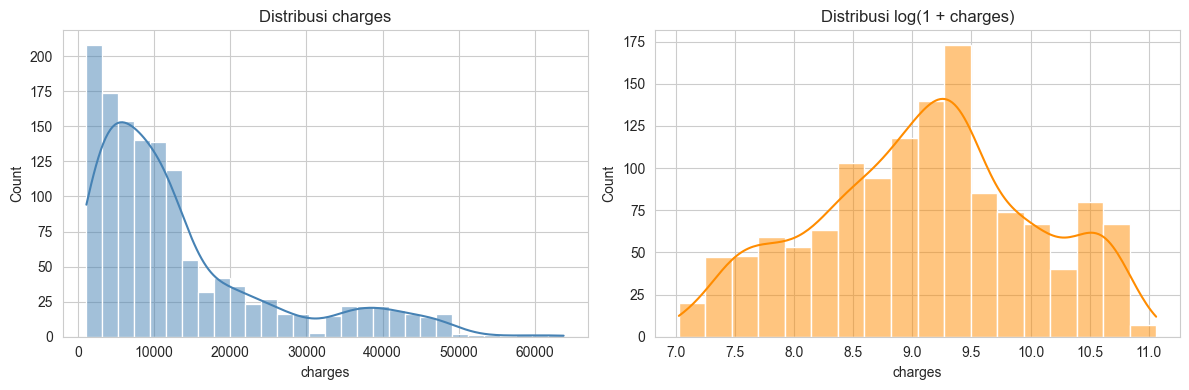

Skewness charges        : 1.516
Skewness log(1+charges) : -0.09


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["charges"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribusi charges")
sns.histplot(np.log1p(df["charges"]), kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribusi log(1 + charges)")
plt.tight_layout()
plt.show()
print("Skewness charges        :", round(df["charges"].skew(), 3))
print("Skewness log(1+charges) :", round(np.log1p(df["charges"]).skew(), 3))

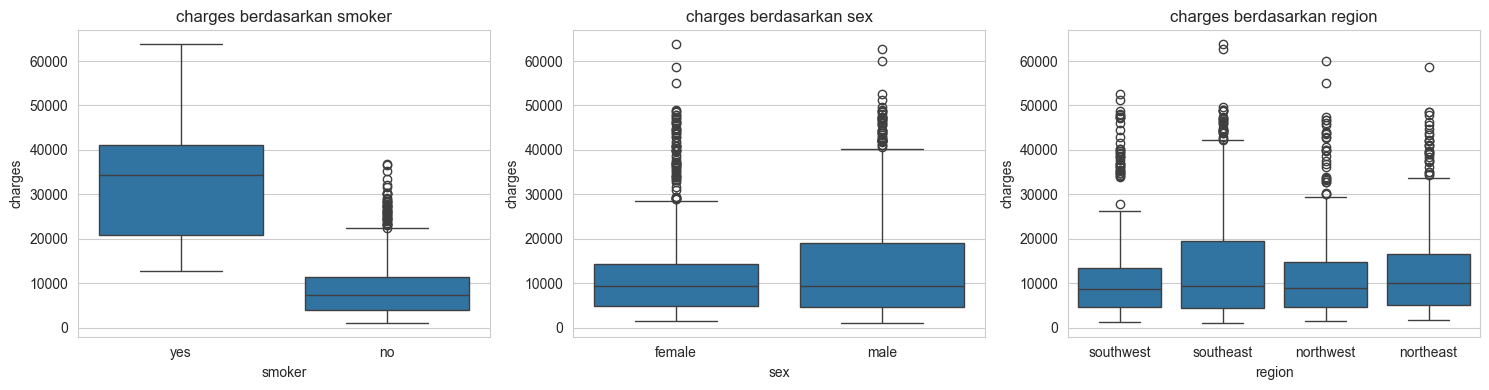

Rata-rata charges per kelompok smoker:
smoker
no     8,434.2683
yes   32,050.2318
Name: charges, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["smoker", "sex", "region"]):
    sns.boxplot(data=df, x=col, y="charges", ax=ax)
    ax.set_title(f"charges berdasarkan {col}")
plt.tight_layout()
plt.show()

print("Rata-rata charges per kelompok smoker:")
print(df.groupby("smoker")["charges"].mean())

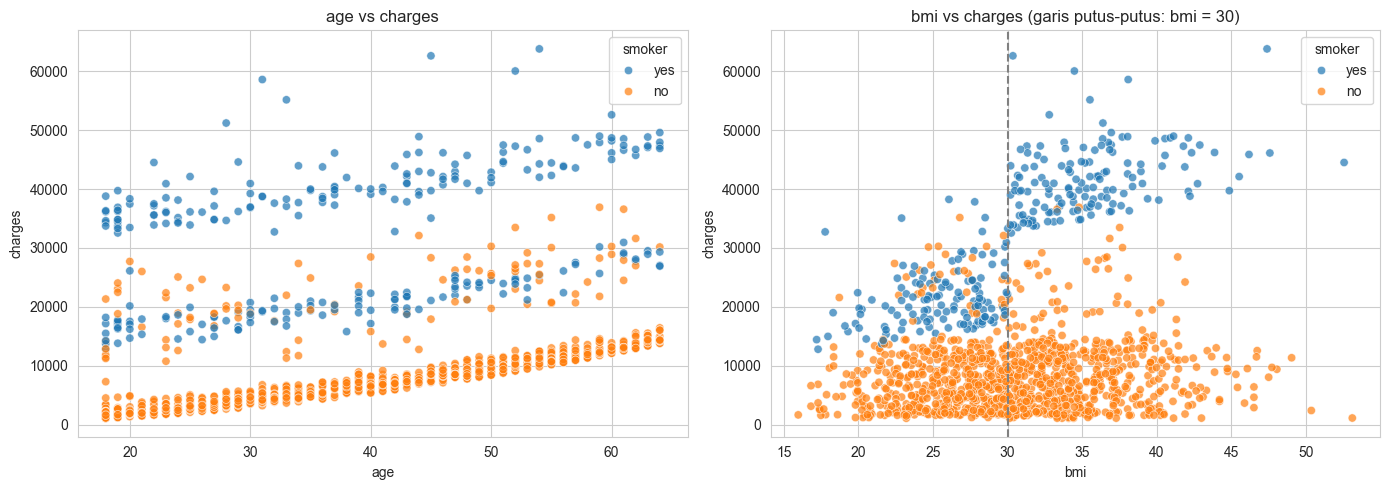

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.7, ax=axes[0])
axes[0].set_title("age vs charges")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7, ax=axes[1])
axes[1].axvline(30, color="gray", linestyle="--")
axes[1].set_title("bmi vs charges (garis putus-putus: bmi = 30)")
plt.tight_layout()
plt.show()

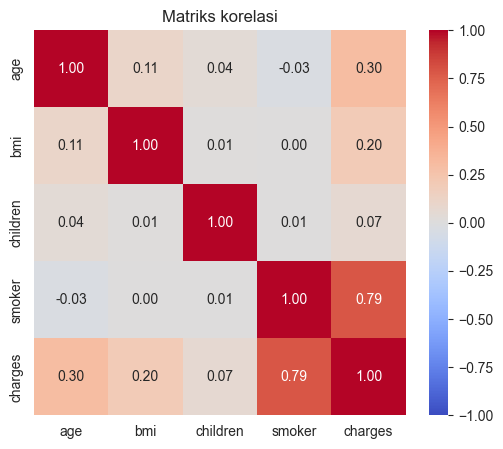

In [11]:
df_corr = df.copy()
df_corr["smoker"] = (df_corr["smoker"] == "yes").astype(int)
plt.figure(figsize=(6, 5))
sns.heatmap(df_corr[["age", "bmi", "children", "smoker", "charges"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriks korelasi")
plt.show()

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [12]:
# Pisahkan fitur (X) dan target (y).
X = df.drop(columns="charges")
y = df["charges"]
print("X:", X.shape, "| y:", y.shape)

X: (1338, 6) | y: (1338,)


In [13]:
# Identifikasi kolom numerik dan kategorikal.
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
print("Kolom numerik    :", num_cols)
print("Kolom kategorikal:", cat_cols)

Kolom numerik    : ['age', 'bmi', 'children']
Kolom kategorikal: ['sex', 'smoker', 'region']


In [14]:
# Bagi data menjadi train set dan test set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (1070, 6) | Test: (268, 6)


In [15]:
# Buat preprocessing untuk fitur numerik dan kategorikal.
preprocess_scaled = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols),
])

# (b) Untuk Decision Tree: numerik apa adanya (tanpa scaling) + kategorikal One-Hot.
preprocess_tree = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols),
])

# Cross-validation yang dipakai konsisten untuk semua eksperimen tuning (hanya pada data train).
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Tempat menyimpan model terlatih dan prediksinya untuk evaluasi di bagian 4.
models, preds = {}, {}

# Pratinjau hasil transformasi
prep_preview = preprocess_scaled.fit(X_train)
cols_out = prep_preview.get_feature_names_out()
print("Fitur setelah preprocessing:", list(cols_out))
pd.DataFrame(prep_preview.transform(X_train.head()), columns=cols_out)

Fitur setelah preprocessing: ['num__age', 'num__bmi', 'num__children', 'cat__sex_male', 'cat__smoker_yes', 'cat__region_northwest', 'cat__region_southeast', 'cat__region_southwest']


,num__age,num__bmi,num__children,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest
0,0.4722,-1.7565,0.7343,0.0000,0.0000,1.0000,0.0000,0.0000
1,0.5433,-1.0331,-0.9112,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.8987,-0.9437,-0.9112,0.0000,0.0000,0.0000,1.0000,0.0000
3,-0.0254,0.6224,3.2026,0.0000,0.0000,0.0000,1.0000,0.0000
4,1.0409,-1.5049,1.5571,0.0000,0.0000,1.0000,0.0000,0.0000


# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [16]:
# Inisialisasi dan latih Linear Regression.
lin_reg = Pipeline([
    ("prep", preprocess_scaled),
    ("model", LinearRegression()),
])
lin_reg.fit(X_train, y_train)
models["Linear Regression"] = lin_reg

coef = pd.Series(lin_reg.named_steps["model"].coef_, index=cols_out).sort_values()
print("Intercept:", round(lin_reg.named_steps["model"].intercept_, 2))
print("Koefisien:")
print(coef)

Intercept: 8955.24
Koefisien:
cat__region_southwest     -809.7994
cat__region_southeast     -657.8643
cat__region_northwest     -370.6773
cat__sex_male              -18.5917
num__children              516.8902
num__bmi                 2,036.2281
num__age                 3,614.9754
cat__smoker_yes         23,651.1289
dtype: float64


In [17]:
# Lakukan prediksi pada test set.
preds["Linear Regression"] = lin_reg.predict(X_test)
print("5 prediksi pertama:", preds["Linear Regression"][:5].round(2))
print("5 nilai aktual    :", y_test.values[:5])

5 prediksi pertama: [ 8969.55  7068.75 36858.41  9454.68 26973.17]
5 nilai aktual    : [ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918 ]


## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [18]:
# Buat fitur polynomial dan latih model.
poly_pipe = Pipeline([
    ("prep", preprocess_scaled),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression()),
])
poly_grid = GridSearchCV(
    poly_pipe, {"poly__degree": [1, 2, 3, 4]},
    cv=cv, scoring="neg_root_mean_squared_error", return_train_score=True
)
poly_grid.fit(X_train, y_train)

poly_cv = pd.DataFrame({
    "degree": poly_grid.cv_results_["param_poly__degree"],
    "CV RMSE (train fold)": -poly_grid.cv_results_["mean_train_score"],
    "CV RMSE (validasi)": -poly_grid.cv_results_["mean_test_score"],
})
print(poly_cv.to_string(index=False))
print("\nDegree terbaik:", poly_grid.best_params_)

poly_reg = poly_grid.best_estimator_
models["Polynomial Regression"] = poly_reg

 degree  CV RMSE (train fold)  CV RMSE (validasi)
      1            6,100.1986          6,123.3538
      2            4,760.5732          4,887.2768
      3            4,513.1208          5,144.4144
      4            4,089.4962          6,469.7834

Degree terbaik: {'poly__degree': 2}


In [19]:
# Lakukan prediksi pada test set.
preds["Polynomial Regression"] = poly_reg.predict(X_test)
print("5 prediksi pertama:", preds["Polynomial Regression"][:5].round(2))
print("5 nilai aktual    :", y_test.values[:5])

5 prediksi pertama: [11215.72  6055.23 33306.27 10833.8  29082.43]
5 nilai aktual    : [ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918 ]


## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [20]:
# Inisialisasi dan latih Ridge Regression.
ridge_pipe = Pipeline([("prep", preprocess_scaled), ("model", Ridge(random_state=RANDOM_STATE))])
ridge_grid = GridSearchCV(
    ridge_pipe, {"model__alpha": np.logspace(-3, 3, 13)},
    cv=cv, scoring="neg_root_mean_squared_error"
)
ridge_grid.fit(X_train, y_train)

print("Alpha terbaik :", ridge_grid.best_params_["model__alpha"])
print("CV RMSE terbaik:", round(-ridge_grid.best_score_, 2))
ridge_reg = ridge_grid.best_estimator_
models["Ridge Regression"] = ridge_reg

Alpha terbaik : 0.31622776601683794
CV RMSE terbaik: 6123.31


In [21]:
# Lakukan prediksi pada test set.
preds["Ridge Regression"] = ridge_reg.predict(X_test)
print("5 prediksi pertama:", preds["Ridge Regression"][:5].round(2))
print("5 nilai aktual    :", y_test.values[:5])

5 prediksi pertama: [ 8975.25  7076.   36819.08  9464.31 26941.6 ]
5 nilai aktual    : [ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918 ]


## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [22]:
# Inisialisasi dan latih Lasso Regression.
lasso_pipe = Pipeline([("prep", preprocess_scaled), ("model", Lasso(max_iter=50000, random_state=RANDOM_STATE))])
lasso_grid = GridSearchCV(
    lasso_pipe, {"model__alpha": np.logspace(-2, 3, 11)},
    cv=cv, scoring="neg_root_mean_squared_error"
)
lasso_grid.fit(X_train, y_train)

print("Alpha terbaik :", lasso_grid.best_params_["model__alpha"])
print("CV RMSE terbaik:", round(-lasso_grid.best_score_, 2))
lasso_reg = lasso_grid.best_estimator_
models["Lasso Regression"] = lasso_reg

lasso_coef = pd.Series(lasso_reg.named_steps["model"].coef_, index=cols_out)
print("\nKoefisien Lasso:")
print(lasso_coef.round(2))
print("Jumlah koefisien yang di-nol-kan:", (lasso_coef == 0).sum())

Alpha terbaik : 31.622776601683793
CV RMSE terbaik: 6118.97

Koefisien Lasso:
num__age                 3,585.6000
num__bmi                 1,970.9900
num__children              488.2200
cat__sex_male               -0.0000
cat__smoker_yes         23,453.8400
cat__region_northwest       -0.0000
cat__region_southeast     -179.2400
cat__region_southwest     -356.8900
dtype: float64
Jumlah koefisien yang di-nol-kan: 2


In [23]:
# Lakukan prediksi pada test set.
preds["Lasso Regression"] = lasso_reg.predict(X_test)
print("5 prediksi pertama:", preds["Lasso Regression"][:5].round(2))
print("5 nilai aktual    :", y_test.values[:5])

5 prediksi pertama: [ 8698.9   7182.42 36750.19  9541.46 26923.12]
5 nilai aktual    : [ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918 ]


## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [24]:
# Inisialisasi dan latih Decision Tree Regressor.
tree_pipe = Pipeline([("prep", preprocess_tree), ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))])
tree_grid = GridSearchCV(
    tree_pipe,
    {"model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
     "model__min_samples_leaf": [1, 5, 10, 20, 30, 50]},
    cv=cv, scoring="neg_root_mean_squared_error"
)
tree_grid.fit(X_train, y_train)

print("Parameter terbaik:", tree_grid.best_params_)
print("CV RMSE terbaik  :", round(-tree_grid.best_score_, 2))

# Pembanding: pohon tanpa pembatasan (cenderung overfit)
tree_full = Pipeline([("prep", preprocess_tree), ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))]).fit(X_train, y_train)
print("\nPohon tanpa batasan -> R2 train:", round(tree_full.score(X_train, y_train), 4),
      "| R2 test:", round(tree_full.score(X_test, y_test), 4))

tree_reg = tree_grid.best_estimator_
models["Decision Tree"] = tree_reg

Parameter terbaik: {'model__max_depth': 4, 'model__min_samples_leaf': 10}
CV RMSE terbaik  : 4583.7

Pohon tanpa batasan -> R2 train: 0.9983 | R2 test: 0.7266


In [25]:
# Lakukan prediksi pada test set.
preds["Decision Tree"] = tree_reg.predict(X_test)
print("5 prediksi pertama:", preds["Decision Tree"][:5].round(2))
print("5 nilai aktual    :", y_test.values[:5])

5 prediksi pertama: [10662.68  5703.34 27503.01 10662.68 35031.66]
5 nilai aktual    : [ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918 ]


## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [28]:
svr_default = svr_pipe.fit(X_train, y_train)
print("SVR default -> R2 test:", round(r2_score(y_test, svr_default.predict(X_test)), 4))

svr_grid = GridSearchCV(
    svr_pipe,
    {"model__regressor__C": [0.1, 1, 10, 100],
     "model__regressor__gamma": ["scale", 0.01, 0.1],
     "model__regressor__epsilon": [0.01, 0.1, 0.2]},
    cv=cv, scoring="neg_root_mean_squared_error"
)
svr_grid.fit(X_train, y_train)

print("Parameter terbaik:", svr_grid.best_params_)
print("CV RMSE terbaik  :", round(-svr_grid.best_score_, 2))
svr_reg = svr_grid.best_estimator_
models["SVR"] = svr_reg

SVR default -> R2 test: 0.8474
Parameter terbaik: {'model__regressor__C': 10, 'model__regressor__epsilon': 0.1, 'model__regressor__gamma': 0.1}
CV RMSE terbaik  : 4800.45


In [29]:
# Lakukan prediksi pada test set.
preds["SVR"] = svr_reg.predict(X_test)
print("5 prediksi pertama:", preds["SVR"][:5].round(2))
print("5 nilai aktual    :", y_test.values[:5])

5 prediksi pertama: [10075.88  6343.77 30328.75  9555.3  26431.56]
5 nilai aktual    : [ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918 ]


# 4. Evaluasi Model

In [32]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.
rows = []
for name, y_pred in preds.items():
    mse = mean_squared_error(y_test, y_pred)
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2 (test)": r2_score(y_test, y_pred),
        "R2 (train)": r2_score(y_train, models[name].predict(X_train)),
    })
results = pd.DataFrame(rows).set_index("Model").sort_values("RMSE")
results.round(4)

,MAE,MSE,RMSE,R2 (test),R2 (train)
Model,,,,,
SVR,"2,386.8271","20,319,848.3133","4,507.7542",0.8691,0.8540
Polynomial Regression,"2,729.5001","20,712,805.9879","4,551.1324",0.8666,0.8418
Decision Tree,"2,697.7654","21,093,484.0046","4,592.7643",0.8641,0.8653
Linear Regression,"4,181.1945","33,596,915.8514","5,796.2847",0.7836,0.7417
Ridge Regression,"4,184.9577","33,611,658.0291","5,797.5562",0.7835,0.7417
Lasso Regression,"4,210.8812","33,881,364.1256","5,820.7701",0.7818,0.7414


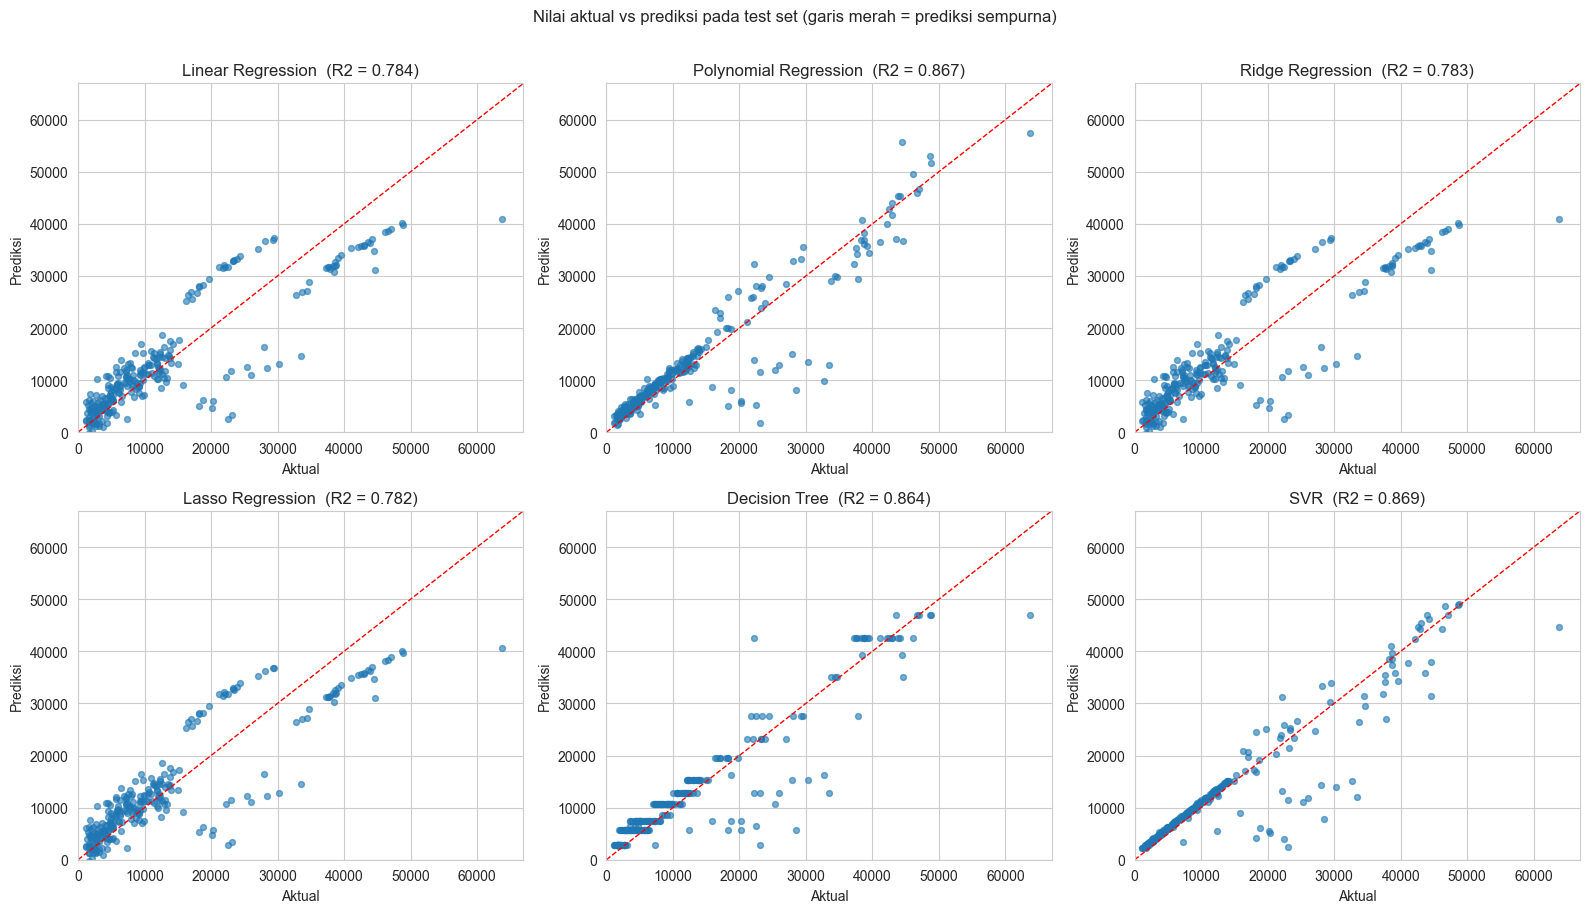

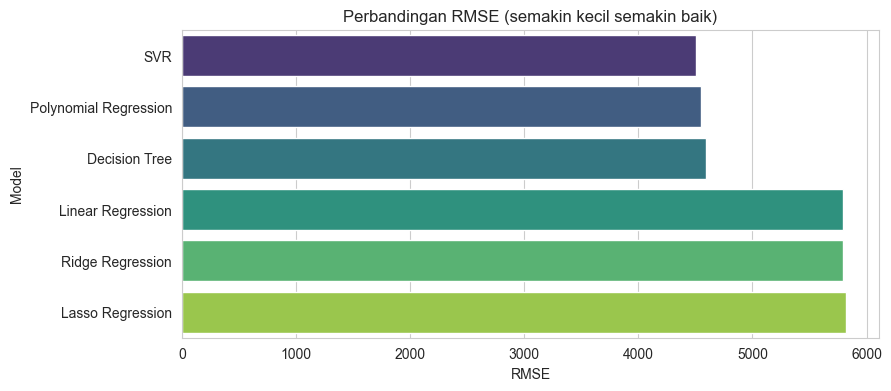

In [33]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
lims = [0, max(y_test.max(), max(p.max() for p in preds.values())) * 1.05]
for ax, (name, y_pred) in zip(axes.ravel(), preds.items()):
    ax.scatter(y_test, y_pred, alpha=0.6, s=18)
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f"{name}  (R2 = {r2_score(y_test, y_pred):.3f})")
    ax.set_xlabel("Aktual"); ax.set_ylabel("Prediksi")
plt.suptitle("Nilai aktual vs prediksi pada test set (garis merah = prediksi sempurna)", y=1.01)
plt.tight_layout()
plt.show()

# Perbandingan RMSE antar model
plt.figure(figsize=(9, 4))
sns.barplot(x=results["RMSE"], y=results.index, palette="viridis")
plt.title("Perbandingan RMSE (semakin kecil semakin baik)")
plt.xlabel("RMSE")
plt.show()

# 5. Analisis

#### Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.


## 5.1 Perbandingan metrik evaluasi (test set)

| Model | MAE | RMSE | R² (test) | R² (train) | Parameter terpilih |
|---|---|---|---|---|---|
| **SVR** | **2.386,83** | **4.507,75** | **0,8691** | 0,8540 | RBF, C=10, gamma=0,1, epsilon=0,1 |
| Polynomial Regression | 2.729,50 | 4.551,13 | 0,8666 | 0,8418 | degree=2 |
| Decision Tree | 2.697,77 | 4.592,76 | 0,8641 | 0,8653 | max_depth=4, min_samples_leaf=10 |
| Linear Regression | 4.181,19 | 5.796,28 | 0,7836 | 0,7417 | - |
| Ridge Regression | 4.184,96 | 5.797,56 | 0,7835 | 0,7417 | alpha≈0,32 |
| Lasso Regression | 4.210,88 | 5.820,77 | 0,7818 | 0,7414 | alpha≈31,6 |

Model terbagi menjadi **dua kelompok yang jelas**:

1. **Kelompok model yang mampu menangkap non-linearitas/interaksi** (SVR, Polynomial degree 2, Decision Tree): RMSE ≈ 4.500-4.600 dan R² ≈ 0,86-0,87.
2. **Kelompok model linear murni** (Linear, Ridge, Lasso): RMSE ≈ 5.800 dan R² ≈ 0,78.

Selisih antar kelompok cukup besar (RMSE turun sekitar 1.250, atau ±22%), sedangkan selisih di dalam kelompok sangat kecil. Selisih ketiga model terbaik (RMSE 4.508 vs 4.551 vs 4.593) tidak cukup besar untuk menyatakan satu model benar-benar lebih unggul, karena hanya dievaluasi pada satu pembagian test set (268 data). Sebagai catatan, pada cross-validation di data train, urutannya sedikit berbeda (Decision Tree ≈ 4.584, SVR ≈ 4.800, Polynomial ≈ 4.887), yang mendukung kesimpulan bahwa ketiganya setara.

## 5.2 Analisis per model

- **Linear Regression.** Menjadi baseline. R² train (0,74) dan test (0,78) sama-sama rendah, artinya model **underfitting**, bukan overfitting. Penyebabnya adalah asumsi hubungan linear dan aditif, padahal dari EDA terlihat efek `bmi` bergantung pada status `smoker`. Koefisien terbesar adalah `smoker_yes` (≈ +23.650), diikuti `age` dan `bmi`, sesuai temuan EDA. Koefisien `sex` hampir nol.
- **Polynomial Regression.** Dengan degree 2, model dapat membentuk suku interaksi (misalnya `smoker × bmi`, `smoker × age`) dan kuadrat `age`, sehingga RMSE turun dari 5.796 menjadi 4.551. Eksperimen degree menunjukkan trade-off bias-variance yang jelas: RMSE validasi terbaik di degree 2 (≈ 4.887), lalu memburuk di degree 3 (≈ 5.144) dan degree 4 (≈ 6.470), sementara error pada data latih terus turun (6.100 → 4.089). Artinya degree tinggi mulai **overfitting**.
- **Ridge Regression.** Alpha terbaik kecil (≈ 0,32), sehingga hasilnya hampir identik dengan Linear Regression. Hal ini wajar: dengan hanya 8 fitur dan 1.070 data latih, model linear tidak mengalami overfitting/multikolinearitas yang berarti, sehingga regularisasi L2 tidak memberi perbaikan. Masalah utama model ini adalah *bias*, bukan *variance*.
- **Lasso Regression.** Alpha terbaik ≈ 31,6 dan Lasso membuat koefisien `sex_male` dan `region_northwest` menjadi tepat nol, yaitu fitur-fitur yang memang lemah pengaruhnya. Lasso berguna sebagai seleksi fitur dan memberi model yang lebih sederhana, tetapi akurasinya sedikit lebih rendah (RMSE 5.821) karena tetap berbasis model linear.
- **Decision Tree.** Pohon tanpa batasan **sangat overfit** (R² train 0,998 vs R² test 0,727). Setelah dibatasi (`max_depth=4`, `min_samples_leaf=10`), R² test naik menjadi 0,864 dan gap train-test hilang (0,865 vs 0,864). Struktur pohon secara alami menangkap interaksi seperti "perokok DAN BMI > 30", sehingga tidak perlu feature engineering manual. Kelemahannya, prediksinya berbentuk anak tangga (nilai konstan per daun), yang terlihat pada plot aktual vs prediksi.
- **SVR.** Hasil terbaik secara MAE (2.387, jauh lebih kecil dibanding model lain) dan RMSE. Kernel RBF mampu memodelkan hubungan non-linear secara mulus. SVR default (C=1) sudah menghasilkan R² test 0,847, dan tuning menaikkannya menjadi 0,869. MAE SVR yang lebih rendah menunjukkan SVR lebih akurat pada sebagian besar data (tagihan kecil-menengah), karena fungsi loss ε-insensitive tidak terlalu terpengaruh oleh outlier tagihan besar.

## 5.3 Pengaruh preprocessing dan parameter

- **One-Hot Encoding** diperlukan karena `sex`, `smoker`, dan `region` bertipe teks. Opsi `drop="first"` menghindari dummy variable trap pada model linear.
- **Scaling (StandardScaler)** pada fitur numerik penting bagi SVR, Ridge, dan Lasso, karena ketiganya sensitif terhadap skala fitur (penalti/kernel bergantung pada jarak dan besar koefisien). Pada Linear Regression biasa scaling tidak mengubah prediksi, hanya membuat koefisien sebanding. Decision Tree tidak di-scaling karena pembagian node tidak bergantung pada skala.
- **Scaling target untuk SVR.** `charges` bernilai puluhan ribu, sehingga `epsilon` dan `C` tidak sebanding dengan skalanya jika target dipakai apa adanya. Karena itu target di-scaling dengan `TransformedTargetRegressor`, lalu prediksi dikembalikan ke skala asli.
- **Tuning dilakukan dengan 5-fold cross-validation hanya pada data train**, sehingga test set benar-benar belum "terlihat" saat memilih parameter dan estimasi performanya lebih jujur.
- **Parameter yang paling berpengaruh**: degree pada Polynomial, `max_depth`/`min_samples_leaf` pada Decision Tree, dan `C`/`gamma` pada SVR. Alpha pada Ridge dan Lasso hampir tidak mengubah hasil karena masalahnya ada pada kapasitas model, bukan regularisasi.


# 6. Kesimpulan dan Saran

#### Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.


## 6.1 Kesimpulan

1. Dari enam model yang dibandingkan, **SVR memberikan performa terbaik** pada test set (MAE 2.386,83; RMSE 4.507,75; R² 0,8691), tetapi **Polynomial Regression (degree 2) dan Decision Tree (max_depth=4) hampir setara** (R² 0,8666 dan 0,8641). Perbedaan di antara ketiganya kecil dan belum tentu signifikan secara statistik.
2. **Linear Regression, Ridge, dan Lasso** menghasilkan performa yang hampir sama (R² ≈ 0,78) dan jelas lebih rendah. Hubungan antara fitur dan biaya medis **tidak linear murni**, terutama karena interaksi antara `smoker` dan `bmi`. Regularisasi tidak membantu karena masalahnya adalah underfitting, bukan overfitting.
3. **Preprocessing dan tuning berpengaruh besar**: One-Hot Encoding dan scaling membuat model berbasis jarak/penalti bekerja baik, pembatasan kedalaman mencegah overfitting pada Decision Tree (R² test 0,727 menjadi 0,864), pemilihan degree mencegah overfitting pada Polynomial, dan scaling target diperlukan agar SVR bekerja optimal.
4. Fitur yang paling menentukan biaya adalah **status perokok**, diikuti **usia** dan **BMI**. Fitur `sex` dan `region` hampir tidak berpengaruh (koefisien Lasso nol atau kecil).

## 6.2 Saran

- **Feature engineering**: tambahkan fitur interaksi eksplisit seperti `smoker × bmi` atau indikator `bmi > 30`, lalu coba lagi pada model linear. Kemungkinan besar model sederhana ini bisa mendekati performa model non-linear dengan tetap mudah diinterpretasi.
- **Transformasi target**: karena `charges` condong ke kanan, coba memodelkan `log(charges)` lalu mengembalikannya ke skala asli.
- **Evaluasi lebih kuat**: gunakan cross-validation berulang pada seluruh data (bukan hanya satu split) untuk membandingkan SVR, Polynomial, dan Decision Tree secara lebih adil.
- **Model ensemble**: coba Random Forest atau Gradient Boosting, yang umumnya lebih stabil daripada satu Decision Tree untuk data tabular seperti ini.
- **Tuning lebih luas**: perluas grid pada SVR (misalnya `C` dan `gamma` lebih besar), Polynomial + Ridge/Lasso (untuk degree 3 ke atas), dan `min_samples_split`/`ccp_alpha` pada Decision Tree.
